In [1]:
from datasets import load_dataset

# 1. 콩 잎사귀 질병 데이터셋 다운로드
dataset = load_dataset("beans")

# 2. 클래스(라벨) 이름 추출
labels = dataset["train"].features["labels"].names

# 3. 모델이 이해할 수 있도록 라벨 텍스트와 숫자를 서로 변환하는 사전(Dictionary) 생성
label2id = {label: str(i) for i, label in enumerate(labels)}
id2label = {str(i): label for i, label in enumerate(labels)}

print(f"클래스 종류: {labels}")
print(f"라벨->숫자: {label2id}")

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/144M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/18.5M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/17.7M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1034 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/133 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/128 [00:00<?, ? examples/s]

클래스 종류: ['angular_leaf_spot', 'bean_rust', 'healthy']
라벨->숫자: {'angular_leaf_spot': '0', 'bean_rust': '1', 'healthy': '2'}


In [2]:
from transformers import AutoImageProcessor
from torchvision.transforms import RandomResizedCrop, Resize, CenterCrop, Compose, Normalize, ToTensor

# 1. 사용할 사전학습 모델 이름
model_checkpoint = "google/vit-base-patch16-224-in21k"

# 2. 모델에 맞는 이미지 처리기 불러오기
image_processor = AutoImageProcessor.from_pretrained(model_checkpoint)

# 3. 이미지 정규화 (모델이 학습했던 이미지의 밝기/색상 기준에 맞춤)
normalize = Normalize(mean=image_processor.image_mean, std=image_processor.image_std)

# 4. 이미지 크기 설정 (ViT 모델은 기본적으로 224x224 사이즈를 사용)
size = (image_processor.size["height"], image_processor.size["width"])

# 5. 학습용 이미지 전처리 (데이터 증강 기법 적용: 이미지를 자르고 크기를 조정하여 다양성 확보)
train_transforms = Compose([
    RandomResizedCrop(size),
    ToTensor(),
    normalize,
])

# 6. 검증/테스트용 이미지 전처리 (평가를 위해 원본을 해치지 않고 중앙만 자름)
val_transforms = Compose([
    Resize(size),
    CenterCrop(size),
    ToTensor(),
    normalize,
])

# 7. 데이터셋에 전처리를 적용하는 함수
def preprocess_train(example_batch):
    example_batch["pixel_values"] = [train_transforms(image.convert("RGB")) for image in example_batch["image"]]
    return example_batch

def preprocess_val(example_batch):
    example_batch["pixel_values"] = [val_transforms(image.convert("RGB")) for image in example_batch["image"]]
    return example_batch

# 8. 전처리 적용 (실제 데이터가 쓰일 때 변환되도록 설정)
train_ds = dataset['train'].with_transform(preprocess_train)
val_ds = dataset['validation'].with_transform(preprocess_val)
test_ds = dataset['test'].with_transform(preprocess_val)

print("데이터 전처리 설정이 완료되었습니다.")

데이터 전처리 설정이 완료되었습니다.


In [3]:
from transformers import AutoModelForImageClassification

# 사전학습된 모델 불러오기
model = AutoModelForImageClassification.from_pretrained(
    model_checkpoint,
    num_labels=len(labels),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
)

print("\n모델이 성공적으로 로드되었습니다. (분류기 헤드가 교체됨)")

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                 | Status     | 
--------------------+------------+-
pooler.dense.bias   | UNEXPECTED | 
pooler.dense.weight | UNEXPECTED | 
classifier.weight   | MISSING    | 
classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



모델이 성공적으로 로드되었습니다. (분류기 헤드가 교체됨)


In [5]:
import evaluate
import numpy as np
import torch

# 1. 정확도(Accuracy) 평가 지표 불러오기
metric = evaluate.load("accuracy")

# 2. 모델의 예측값과 실제 정답을 비교하여 정확도를 계산하는 함수
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    # 확률이 가장 높은 클래스를 최종 예측값으로 선택
    predictions = np.argmax(predictions, axis=1)
    return metric.compute(predictions=predictions, references=labels)

# 3. 데이터 콜레이터 (여러 개의 이미지를 하나의 '배치(Batch)' 묶음으로 만들어주는 역할)
def collate_fn(examples):
    pixel_values = torch.stack([example["pixel_values"] for example in examples])
    labels = torch.tensor([example["labels"] for example in examples])
    return {"pixel_values": pixel_values, "labels": labels}

print("평가 함수와 데이터 콜레이터가 준비되었습니다.")

평가 함수와 데이터 콜레이터가 준비되었습니다.


In [6]:
from transformers import TrainingArguments, Trainer

# 1. 학습 세부 설정 
args = TrainingArguments(
    output_dir="./vit-beans-finetuned", 
    remove_unused_columns=False,        
    eval_strategy="epoch",              
    save_strategy="epoch",              
    learning_rate=5e-5,                 
    per_device_train_batch_size=16,     
    per_device_eval_batch_size=16,      
    num_train_epochs=3,                 
    load_best_model_at_end=True,        
    metric_for_best_model="accuracy",   
    logging_steps=10,                   
    fp16=True, # RTX 4060 Ti 성능 향상을 위한 옵션
)

# 2. 트레이너 객체 생성 
trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    processing_class=image_processor, # <--- 여기가 'tokenizer'에서 변경되었습니다!
    compute_metrics=compute_metrics,
    data_collator=collate_fn,
)

# 3. 학습 시작!
print("학습을 시작합니다...")
trainer.train()

학습을 시작합니다...


Epoch,Training Loss,Validation Loss,Accuracy
1,0.247934,0.167069,0.962406
2,0.141509,0.125427,0.969925
3,0.089597,0.117028,0.969925


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=195, training_loss=0.26508435683372694, metrics={'train_runtime': 51.8669, 'train_samples_per_second': 59.807, 'train_steps_per_second': 3.76, 'total_flos': 2.4038230623573197e+17, 'train_loss': 0.26508435683372694, 'epoch': 3.0})


[최종 성능 평가]
테스트 데이터 정확도: 97.66%

[새로운 이미지 예측 테스트]
이미지의 실제 정답: angular_leaf_spot
모델의 예측 결과:
 - angular_leaf_spot: 확률 94.10%
 - bean_rust: 확률 3.78%
 - healthy: 확률 2.12%


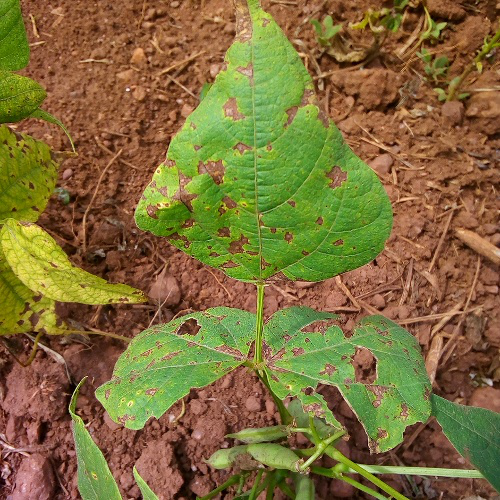

In [7]:
from transformers import pipeline

#  UI 버그 콜백 강제 제거 로직 ---
callbacks_to_remove = [
    cb for cb in trainer.callback_handler.callbacks 
    if cb.__class__.__name__ == "NotebookProgressCallback"
]
for cb in callbacks_to_remove:
    trainer.remove_callback(cb)
# ---------------------------------------------------

# 1. 테스트 데이터셋으로 최종 성능 평가
print("\n[최종 성능 평가]")
test_results = trainer.evaluate(test_ds)
print(f"테스트 데이터 정확도: {test_results['eval_accuracy'] * 100:.2f}%\n")

# 모델 config의 라벨 키값을 문자열에서 정수형으로 변환 ---
trainer.model.config.id2label = {int(k): v for k, v in trainer.model.config.id2label.items()}
trainer.model.config.label2id = {k: int(v) for k, v in trainer.model.config.label2id.items()}
# -------------------------------------------------------------------------

# 2. 파이프라인(손쉬운 추론 도구) 생성
classifier = pipeline("image-classification", model=trainer.model, image_processor=image_processor)

# 3. 테스트 데이터셋에서 이미지 하나 꺼내오기
sample_index = 0
sample_image = dataset['test'][sample_index]['image']

# 정답 라벨도 정수형을 사용하여 가져옵니다
actual_label = trainer.model.config.id2label[dataset['test'][sample_index]['labels']]

print("[새로운 이미지 예측 테스트]")
print(f"이미지의 실제 정답: {actual_label}")

# 4. 모델에게 예측 시키기
prediction = classifier(sample_image)

print("모델의 예측 결과:")
for pred in prediction:
    print(f" - {pred['label']}: 확률 {pred['score'] * 100:.2f}%")

# (선택) 이미지 출력 확인
display(sample_image)